1. Imports & Setup
    + Import libraries
    + Set paths
    + Configure device (CPU/GPU)

# Product Category Summarization with Generative AI

This notebook represents the final stage of the NLP pipeline developed for the Amazon Product Reviews project.

The objective is to generate concise consumer-oriented summaries for each product category identified during the clustering stage. Instead of summarizing individual reviews, the model uses structured information extracted from each product cluster to produce a buying guide highlighting the most relevant products, their strengths, common customer complaints, and purchasing recommendations.

Pipeline:

**Data Cleaning → Sentiment Analysis → Product Clustering → Generative AI Summaries**

In [99]:
# ==========================================================
# Data manipulation
# ==========================================================
import os
import re
import warnings

import numpy as np
import pandas as pd

# ==========================================================
# Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Machine Learning / NLP
# ==========================================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================================
# Hugging Face Transformers
# ==========================================================
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    pipeline
)

# ==========================================================
# Model persistence
# ==========================================================
import joblib

# ==========================================================
# Display options
# ==========================================================
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

warnings.filterwarnings("ignore")

In [100]:
from generative_functions import (
    aggregate_reviews,
    get_top_products,
    get_lowest_products,
    get_review_examples,
    build_prompt,
    generate_summary,
    generate_category_summaries
)

In [101]:
# 1.2 Paths
# ==========================================================
# Data Paths
# ==========================================================

DATA_PATH = "../data/processed"
MODEL_PATH = "../models"

REVIEWS_PATH = f"{DATA_PATH}/reviews_with_clusters.csv"
PRODUCTS_PATH = f"{DATA_PATH}/product_clusters.csv"

SUMMARIES_PATH = f"{DATA_PATH}/category_summaries.csv"
PROMPTS_PATH = f"{DATA_PATH}/category_prompts.csv"

In [102]:
# 1.3 Device Configuration
# ==========================================================
# Device Configuration
# ==========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [103]:
# 1.4 Model Configuration
MODEL_NAME = "google/flan-t5-small"

## 2 – Load Clustered Data

In [104]:
# 2.1 Load the datasets
reviews = pd.read_csv(REVIEWS_PATH)
products = pd.read_csv(PRODUCTS_PATH)

In [105]:
# 2.2 Verify the datasets
print(f"Reviews dataset shape: {reviews.shape}")
print(f"Products dataset shape: {products.shape}")

Reviews dataset shape: (34624, 14)
Products dataset shape: (38, 8)


### 2.3 Inspect the datasets

In [106]:

reviews.head()

,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins,cluster,cluster_name
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,great for beginner or experienced person. Bought as a gift and she loves it,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...",Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",4.0,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime conte...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes sure that she only accesses sites and content that...",Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets


In [107]:
products.head()

,asins,n_reviews,categories,brand,mean_rating,cluster,cluster_name,rankable
0,B002Y27P6Y,10,"Electronics,Amazon Device Accessories,Kindle Store,Covers,Kindle E-Reader Accessories,Kindle DX (2nd Generation, Global Wireless) Accessories",Amazon Digital Services Inc.,3.500000,1,Accessories & Cables,False
1,B005PB2T0S,5,"Electronics,eBook Readers & Accessories,Covers,Kindle Store,Amazon Device Accessories,Kindle E-Reader Accessories,Kindle (5th Generation) Accessories,Kindle (5th Generation) Covers",Amazon,4.000000,1,Accessories & Cables,False
2,B005PB2T2Q,6,"Amazon Device Accessories,Kindle Store,Kindle Touch (4th Generation) Accessories,Kindle E-Reader Accessories,Covers,Kindle Touch (4th Generation) Covers",Amazon,3.666667,1,Accessories & Cables,False
3,B006GWO5NE,8,"Power Adapters & Cables,Electronics,USB Cables",Amazon,4.875000,1,Accessories & Cables,False
4,B006GWO5WK,13,"Computers/Tablets & Networking,Tablet & eBook Reader Accs,Chargers & Sync Cables,Power Adapters & Cables,Kindle Store,Amazon Device Accessories,Fire Tablet Accessories,Kindle Fire (2nd Generation)...",Amazon,2.461538,1,Accessories & Cables,False


In [108]:
# 2.4 Check the available columns
print("Reviews columns:")
print(reviews.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())


Reviews columns:
['name', 'brand', 'categories', 'reviews.rating', 'reviews.text', 'reviews.title', 'reviews.numHelpful', 'reviews.doRecommend', 'sentiment', 'id', 'keys', 'asins', 'cluster', 'cluster_name']

Products columns:
['asins', 'n_reviews', 'categories', 'brand', 'mean_rating', 'cluster', 'cluster_name', 'rankable']


## 3. Exploratory Analysis

In [109]:
# 3.1 Dataset Overview

print("Reviews dataset")
display(reviews.head())

print("\nProducts dataset")
display(products.head())

Reviews dataset


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins,cluster,cluster_name
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,great for beginner or experienced person. Bought as a gift and she loves it,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...",Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",4.0,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime conte...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets",5.0,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes sure that she only accesses sites and content that...",Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmag...",B01AHB9CN2,0,Fire Tablets



Products dataset


,asins,n_reviews,categories,brand,mean_rating,cluster,cluster_name,rankable
0,B002Y27P6Y,10,"Electronics,Amazon Device Accessories,Kindle Store,Covers,Kindle E-Reader Accessories,Kindle DX (2nd Generation, Global Wireless) Accessories",Amazon Digital Services Inc.,3.500000,1,Accessories & Cables,False
1,B005PB2T0S,5,"Electronics,eBook Readers & Accessories,Covers,Kindle Store,Amazon Device Accessories,Kindle E-Reader Accessories,Kindle (5th Generation) Accessories,Kindle (5th Generation) Covers",Amazon,4.000000,1,Accessories & Cables,False
2,B005PB2T2Q,6,"Amazon Device Accessories,Kindle Store,Kindle Touch (4th Generation) Accessories,Kindle E-Reader Accessories,Covers,Kindle Touch (4th Generation) Covers",Amazon,3.666667,1,Accessories & Cables,False
3,B006GWO5NE,8,"Power Adapters & Cables,Electronics,USB Cables",Amazon,4.875000,1,Accessories & Cables,False
4,B006GWO5WK,13,"Computers/Tablets & Networking,Tablet & eBook Reader Accs,Chargers & Sync Cables,Power Adapters & Cables,Kindle Store,Amazon Device Accessories,Fire Tablet Accessories,Kindle Fire (2nd Generation)...",Amazon,2.461538,1,Accessories & Cables,False


In [110]:
# 3.2 Dataset Shapes
print(f"Reviews: {reviews.shape}")
print(f"Products: {products.shape}")

Reviews: (34624, 14)
Products: (38, 8)


In [111]:
# 3.3 Product Categories
reviews["cluster_name"].value_counts()

cluster_name
Fire Tablets                  17627
Echo, Fire TV & Smart Home    12345
Kindle E-Readers               4092
Accessories & Cables            560
Name: count, dtype: int64

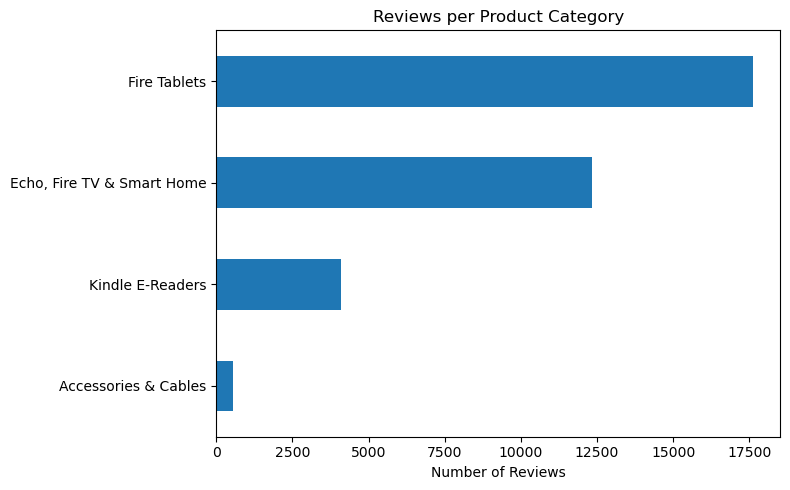

In [112]:
# 3.4 Distribution of Reviews
plt.figure(figsize=(8,5))

reviews["cluster_name"].value_counts().sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Reviews")
plt.ylabel("")
plt.title("Reviews per Product Category")

plt.tight_layout()
plt.show()

In [113]:
# 3.5 Average Rating per Category
reviews.groupby("cluster_name")["reviews.rating"].mean().sort_values(ascending=False)

cluster_name
Kindle E-Readers              4.752199
Echo, Fire TV & Smart Home    4.677602
Fire Tablets                  4.489760
Accessories & Cables          4.292857
Name: reviews.rating, dtype: float64

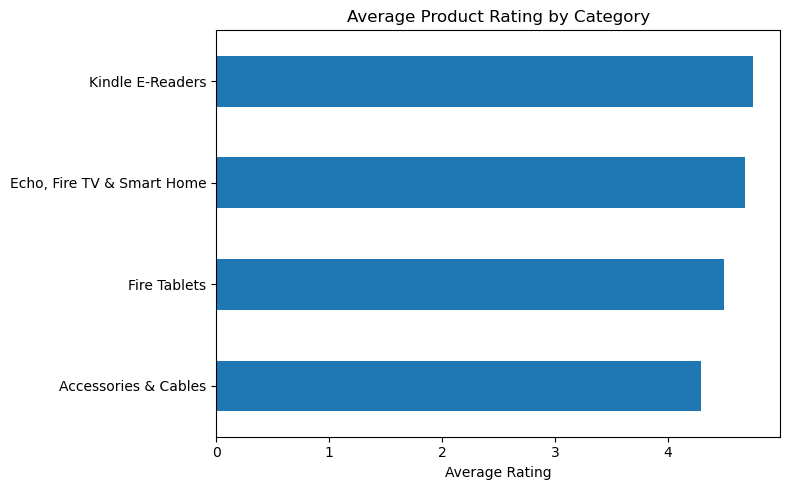

In [114]:
plt.figure(figsize=(8,5))

reviews.groupby("cluster_name")["reviews.rating"].mean().sort_values().plot(
    kind="barh"
)

plt.xlabel("Average Rating")
plt.ylabel("")
plt.title("Average Product Rating by Category")

plt.tight_layout()
plt.show()

In [115]:
# 3.6 Number of Products per Category

products.groupby("cluster_name")["asins"].nunique().sort_values()

cluster_name
Kindle E-Readers               6
Echo, Fire TV & Smart Home     8
Accessories & Cables          10
Fire Tablets                  14
Name: asins, dtype: int64

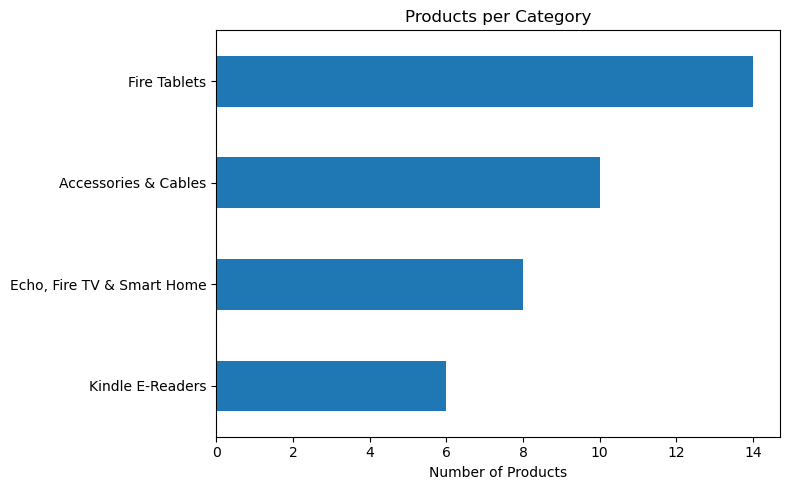

In [116]:
# 3.6.2 Number of Products per Category

plt.figure(figsize=(8,5))

(
    products.groupby("cluster_name")["asins"]
    .nunique()
    .sort_values()
    .plot(kind="barh")
)

plt.xlabel("Number of Products")
plt.ylabel("")
plt.title("Products per Category")

plt.tight_layout()
plt.show()

## 4. Load the Generative Model

In [117]:
# 4.1 Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [118]:
# ==========================================================
# 4.2 Load the model
# ==========================================================

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    low_cpu_mem_usage=True
)

In [119]:
# 4.3 Move the model to the selected device
model.to(DEVICE)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [120]:
# 4.4 Verify everything loaded correctly
print("Model loaded successfully!")
print(f"Model: {MODEL_NAME}")
print(f"Device: {DEVICE}")

Model loaded successfully!
Model: google/flan-t5-small
Device: cpu


## 5. Prepare Product Information

In [121]:
# ==========================================================
# 5.1 Reviews per Category
# ==========================================================

reviews.groupby(
    "cluster_name"
).size().sort_values(
    ascending=False
)

cluster_name
Fire Tablets                  17627
Echo, Fire TV & Smart Home    12345
Kindle E-Readers               4092
Accessories & Cables            560
dtype: int64

In [122]:
# 5.1.2 Aggregate Reviews by Category

category_reviews = aggregate_reviews(reviews)

category_reviews.head()

,cluster_name,reviews.text
0,Accessories & Cables,[Finally received the Kindle Lighted Leather Cover for the newest version Kindle. It is VERY lightweight and I had to double and triple check the description considering it states this is a leathe...
1,"Echo, Fire TV & Smart Home","[I am not a casual user of on-demand content and devices. Having tried smart tv's from 3 brands, smart dvd/bluray players, Apple TV, WDTV, HTPC, Chromecast and too many other competing products to..."
2,Fire Tablets,"[This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease., great for beginner or experienced person. Bought a..."
3,Kindle E-Readers,"[Very lightweight and portable with excellent battery life., I like this so much more than the Voyage. The shape makes for easier holding. I only wish this devise was maybe 2 inches taller then it..."


In [123]:
# ==========================================================
# 5.2 Identify the Top Products
# ==========================================================

top_products = get_top_products(
    products,
    reviews,
    top_n=3
)

top_products[
    [
        "cluster_name",
        "name",
        "mean_rating",
        "n_reviews"
    ]
]

,cluster_name,name,mean_rating,n_reviews
0,Accessories & Cables,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.500000,16
1,Accessories & Cables,"Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,\r\nAmazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,",4.438903,401
2,Accessories & Cables,Amazon,4.205479,73
3,"Echo, Fire TV & Smart Home",Amazon Fire Tv,4.707278,5056
4,"Echo, Fire TV & Smart Home","Echo (White),,,\r\nEcho (White),,,",4.671098,6619
5,"Echo, Fire TV & Smart Home","Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.666667,15
6,Fire Tablets,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.600000,30
7,Fire Tablets,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",4.588608,158
8,Fire Tablets,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",4.586709,2814
9,Kindle E-Readers,"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",4.862745,51


In [124]:
# ==========================================================
# 5.3 Identify the Lowest Rated Product
# ==========================================================

lowest_products = get_lowest_products(
    products,
    reviews
)

lowest_products[
    [
        "cluster_name",
        "name",
        "mean_rating",
        "n_reviews"
    ]
]

,cluster_name,name,mean_rating,n_reviews
0,Accessories & Cables,Amazon,3.066667,15
1,"Echo, Fire TV & Smart Home",Amazon Echo,4.531447,636
2,Fire Tablets,"Echo (White),,,\r\nEcho (White),,,",4.424731,372
3,Kindle E-Readers,"Amazon Kindle Fire Hd (3rd Generation) 8gb,,,\r\nAmazon Kindle Fire Hd (3rd Generation) 8gb,,,",4.533019,212


In [125]:
# ==========================================================
# 5.4 Extract Review Examples
# ==========================================================

positive_examples = get_review_examples(
    reviews,
    sentiment="Positive",
    n_examples=5
)

negative_examples = get_review_examples(
    reviews,
    sentiment="Negative",
    n_examples=5
)

print("Positive examples")
display(positive_examples.head())

print("\nNegative examples")
display(negative_examples.head())

Positive examples


,cluster_name,reviews.text
0,Accessories & Cables,[Finally received the Kindle Lighted Leather Cover for the newest version Kindle. It is VERY lightweight and I had to double and triple check the description considering it states this is a leathe...
1,"Echo, Fire TV & Smart Home","[I am not a casual user of on-demand content and devices. Having tried smart tv's from 3 brands, smart dvd/bluray players, Apple TV, WDTV, HTPC, Chromecast and too many other competing products to..."
2,Fire Tablets,"[This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease., great for beginner or experienced person. Bought a..."
3,Kindle E-Readers,"[Very lightweight and portable with excellent battery life., I like this so much more than the Voyage. The shape makes for easier holding. I only wish this devise was maybe 2 inches taller then it..."



Negative examples


,cluster_name,reviews.text
0,Accessories & Cables,"[Most buyers will have a phone or other charger that will work so you probably don't need to buy this., cheap - need to constantly make sure plugged in - slightly too small - saved some bucks ther..."
1,"Echo, Fire TV & Smart Home","[Stay away from the certified refurbished Amazon Fire TV. I received two Certified Refurbished defective fire TVs. The first the screen looked half corrupted, see the pictures. The second Certifie..."
2,Fire Tablets,"[Didn't have some of the features I was looking for. Returned it the next day. May be good for others, i Bought this around black friday for $60 hoping it would be awesome... it failed so hard i t..."
3,Kindle E-Readers,[This is not an upgrade by any means! My three year old kindle outperformed Oasis.Battery life better than a week with the lights on lowest setting Magnetic connector is poorly designed and grows ...


In [126]:
# ==========================================================
# 6. Prompt Engineering
# ==========================================================

# 6.1 Build Prompt

category = "Fire Tablets"

prompt = build_prompt(
    category=category,
    top_products=top_products,
    lowest_products=lowest_products,
    positive_examples=positive_examples,
    negative_examples=negative_examples
)

print(prompt)


You are an expert technology reviewer.

Write a consumer buying guide between 150 and 200 words.

Category:
Fire Tablets

Top Products:
- Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black
- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta
- All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta

Lowest Rated Product:
- Echo (White),,,
Echo (White),,,

Representative Positive Reviews:
- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
- great for beginner or experienced person. Bought as a gift and she loves it
- Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...
- I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to e

In [127]:
# ==========================================================
# 7. Generate Category Summaries
# ==========================================================

summaries_df = generate_category_summaries(
    reviews=reviews,
    top_products=top_products,
    lowest_products=lowest_products,
    positive_examples=positive_examples,
    negative_examples=negative_examples,
    tokenizer=tokenizer,
    model=model,
    device=DEVICE
)

summaries_df

Generating: Fire Tablets
Finished!
Generating: Kindle E-Readers
Finished!
Generating: Accessories & Cables
Finished!
Generating: Echo, Fire TV & Smart Home
Finished!


,cluster_name,summary
0,Fire Tablets,- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease. - great for beginner or experienced person. Bought...
1,Kindle E-Readers,This is not an upgrade by any means! My three year old kindle outperformed Oasis.Battery life better than a week with the lights on lowest setting Magnetic connector is poorly designed and grows w...
2,Accessories & Cables,Kindle
3,"Echo, Fire TV & Smart Home",Amazon Echo and Roku 3 are the best tv boxes with their high quality and low price.


In [128]:
# ==========================================================
# 8. Save Results
# ==========================================================

summaries_df.to_csv(
    SUMMARIES_PATH,
    index=False
)


print(f"Summaries saved to: {SUMMARIES_PATH}")


Summaries saved to: ../data/processed/category_summaries.csv


# 9. Conclusions

This notebook demonstrated the use of a pretrained generative language model (FLAN-T5) to automatically generate consumer-oriented buying guides from Amazon product reviews.

The workflow integrated the outputs of the previous NLP stages—including sentiment analysis and product clustering—to create structured prompts containing the most relevant information for each product category.

Using these prompts, FLAN-T5 generated concise summaries highlighting:

- The highest-rated products.
- Their main strengths.
- Common customer complaints.
- The lowest-rated product and the reasons it should be avoided.

This approach illustrates how Generative AI can transform thousands of individual customer reviews into clear, readable buying recommendations, making large collections of user-generated content easier to interpret and supporting better purchasing decisions.